# Intercorrélation : mesure de la vitesse du son
Version 2026-02-19

Procédure :
1. Enregistrement avec les micros en utilisant un logiciel dédié
2. Traitement du son avec Python

Attention :
* ne pas avoir un son saturé

In [12]:
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav

fe = 48000  N = 20000
imax : 20000
Δt : 0.0208 ms
Vitesse : 24000.0 m/s


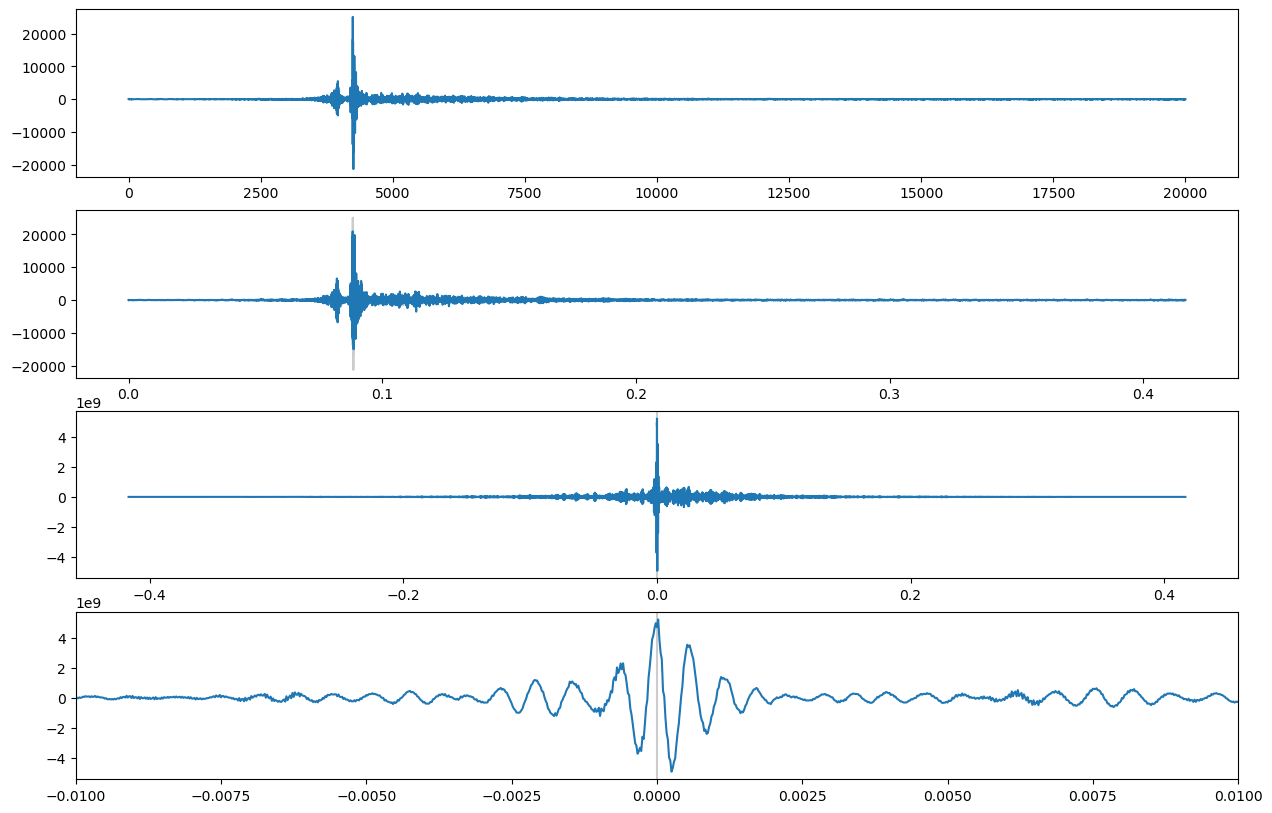

In [17]:
fe, data = wav.read('/home/vinc/tel/ted.wav')

# MÉGA SUPER HYPER IMPORTANT
data = 1. * data

a, b = 40000, 60000

left = data[a:b,0]
right = data[a:b,1]

# Vecteurs temps
N = len(left)              # Nombre d'échantillons 
t = np.arange(N)/fe        # Vecteur temps des signaux enregistrés
tx = np.arange(-N+1,N)/fe  # Vecteur temps de la corrélation

# Corrélation
corr = scipy.signal.correlate(left, right, mode="full")

# Affichage des signaux enregistrés
fig, axs = plt.subplots(4, 1, figsize=(15,10))
axs[0].plot(left)
axs[1].plot(t, left, color='#ccc')
axs[1].plot(t, right-left)
# axs[1].set_xlim([.34, .346])
axs[2].axvline(0, color='#ccc')
axs[2].plot(tx, corr)
axs[3].axvline(0, color='#ccc')
axs[3].plot(tx, corr)
axs[3].set_xlim([-.01, .01])

# Mesure de la vitesse du son
imax = np.argmax(corr)
t = np.abs(tx[imax])
d = 0.5
print(f"fe = {fe}  N = {N}")
print(f"imax : {imax}")
print(f"Δt : {t*1000:.3} ms")
print(f"Vitesse : {d/t} m/s")

(4200.0, 4400.0)

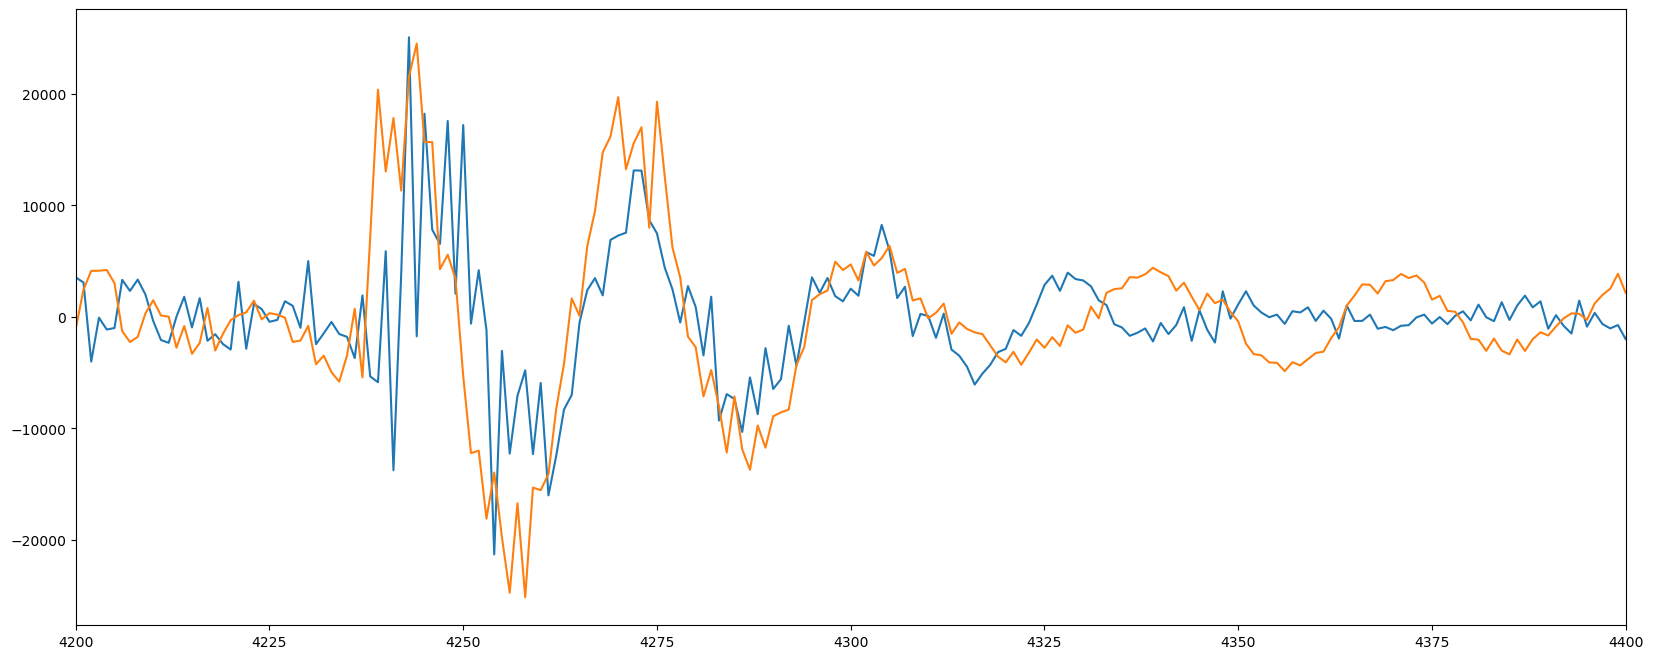

In [24]:
l = np.arange(N)
r = np.arange(N) - 3
plt.figure(figsize=(20,8))
plt.plot(l, left)
plt.plot(r, right)
plt.xlim([4200, 4400])

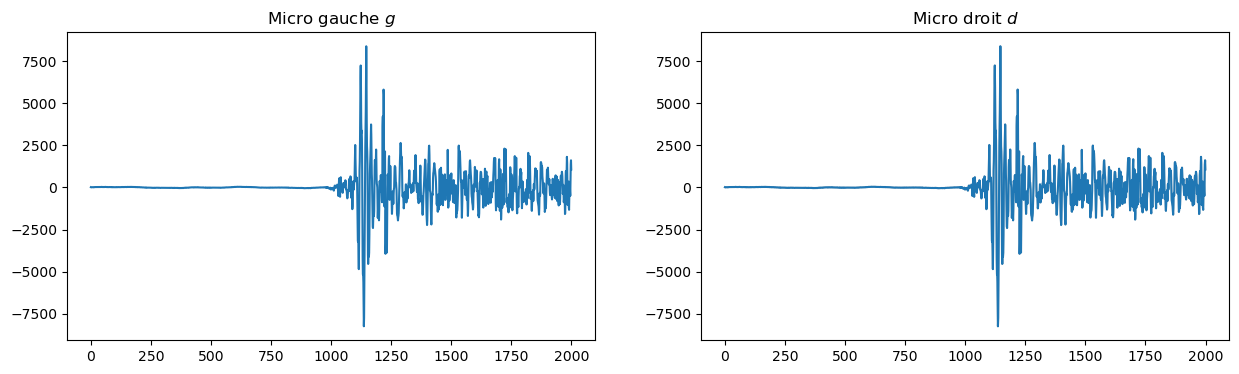

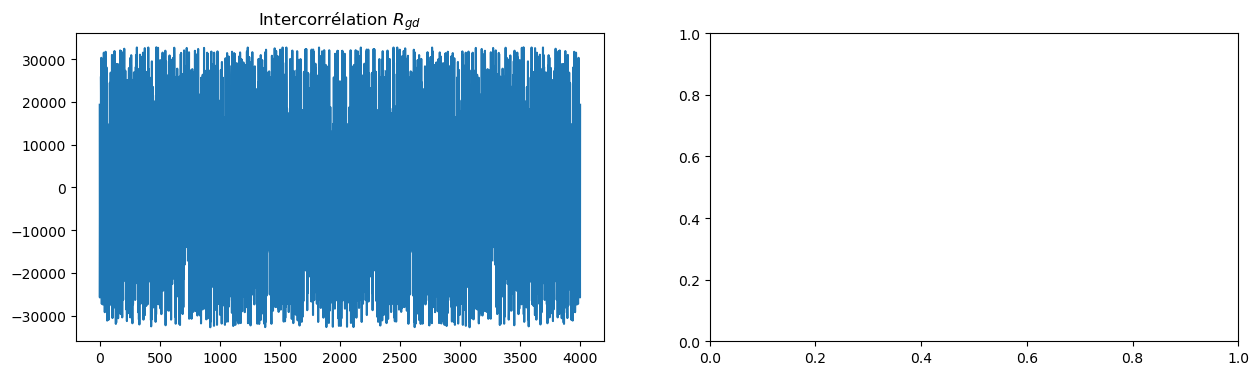

imax : 471
Delta t : 0.03464852607709751
Vitesse : 14.430628272251308 m/s


In [3]:
a, b = 0, data.shape[0]
a, b = 14000, 16000
left = data[a:b,0]
right = data[a:b,1]
# K = 10000
# right = np.concatenate( (left[K:], np.zeros(K)) )
right = left

# Corrélation
corr = scipy.signal.correlate(left, right, mode="full")

# Vecteurs temps
N = len(left)              # Nombre d'échantillons 
# t = np.arange(0,N)/fe      # Vecteur temps des signaux enregistrés
t = np.arange(0,N)
tx = np.arange(-N+1,N)/fe  # Vecteur temps de la corrélation

# Affichage des signaux enregistrés
fig, axs = plt.subplots(1, 2, figsize=(15,4))
axs[0].plot(t, left)
axs[0].set_title("Micro gauche $g$")
axs[1].plot(t, left, color='#ccc')
axs[1].plot(t, right)
axs[1].set_title("Micro droit $d$")
plt.show()

# Affichage de la corrélation
fig, axs = plt.subplots(1, 2, figsize=(15,4))
axs[0].plot(corr)
axs[0].set_title("Intercorrélation $R_{gd}$")
# axs[1].plot(corr)
# axs[1].set_title("Intercorrélation $R_{gd} (zoom)$")
# # axs[1].set_xlim([-.01, .01])
plt.show()

# Mesure de la vitesse du son
imax = np.argmax(corr)
t = np.abs(tx[imax])
d = 0.5
print("imax : "+str(imax))
print("Delta t : "+str(t))
print("Vitesse : "+str(d/t)+" m/s")

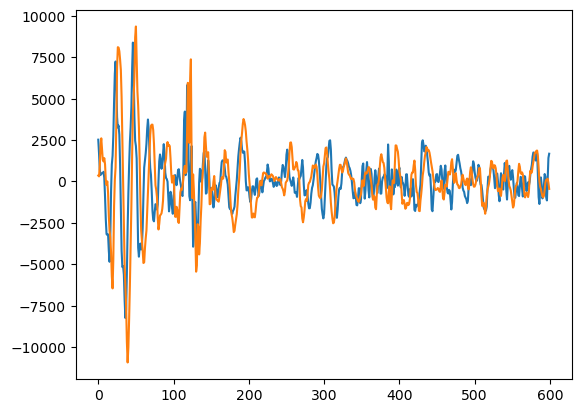

In [18]:
plt.plot(left[600:1200])
plt.plot(right[600:1200])

<hr />

**Notes**
* Si le haut parleur n'est pas branché ou que le son est coupé : faire un bruit à la bouche.
* Réglages sur le portable :
  * Sortie : Speakers - Audio interne
  * Entrée : Microphone - Audio interne (vol 60 %)

<hr />

En plaçant les deux microphones à une distance différente du haut-parleur,
le son produit par celui-ci sera capté à des instants différents par les deux microphones.
En mesurant le délai $t$ entre ces deux instants,
et connaissant la distance $d$ entre les deux microphones,
nous pourrons déduire la vitesse du son $v$ :

$$v = \frac{d}{t}$$

Pour mesurer le délai $t$, on peut utiliser l'intercorrélation qui permet d'avoir le décalage nécessaire pour que les deux sons captés soient similaires.

Pour que la méthode fonctionne bien, il faut que l'intercorrélation soit la plus piquée possible.
Cela implique que le son joué par le haut-parleur ne se répète pas :
on peut donc utiliser un « clap » ou un bruit.

In [ ]:
# Règle le volume avant acquisition
# sound.init_volume()

# Acquisition
fe = 44100             # Fréquence d'échantillonage
left, right, samples = sound.play_and_record("whitenoise", 2)

# Suppression des premiers échantillons (vraiment utile ?)
left = left[100000:]
right = right[100000:]

# Corrélation
corr = scipy.signal.correlate(left, right, mode="full")

# Vecteurs temps
N = len(left)              # Nombre d'échantillons 
t = np.arange(0,N)/fe      # Vecteur temps des signaux enregistrés
tx = np.arange(-N+1,N)/fe  # Vecteur temps de la corrélation

# Affichage des signaux enregistrés
fig, axs = plt.subplots(1, 2, figsize=(15,4))
axs[0].plot(t, left)
axs[0].set_title("Micro gauche $g$")
axs[1].plot(t, right)
axs[1].set_title("Micro droite $d$")
plt.show()

# Affichage de la corrélation
plt.figure()
fig, axs = plt.subplots(1, 2, figsize=(15,4))
axs[0].plot(tx, corr)
axs[0].set_title("Intercorrélation $R_{gd}$")
axs[1].plot(tx, corr)
axs[1].set_title("Intercorrélation $R_{gd} (zoom)$")
axs[1].set_xlim([-.01, .01])
plt.show()

# Mesure de la vitesse du son
imax = np.argmax(corr)
t = np.abs(tx[imax])
d = 0.5
print("imax : "+str(imax))
print("Delta t : "+str(t))
print("Vitesse : "+str(d/t)+" m/s")